In [1]:
from utils.DataPreprocessing import dataloader
from loguru import logger
import torch
import os

lag = 20
path = os.path.dirname(os.path.dirname(os.getcwd()))
print(path)
data = dataloader(path=path, lag=lag)

2024-04-10 12:37:44.557 | INFO     | utils.DataPreprocessing:load_csv:127 - shape: (11_103, 3)
┌───────────┬─────────────┬────────────┐
│ AVG_TEMP  ┆ AVG_TEMP_DC ┆ date       │
│ ---       ┆ ---         ┆ ---        │
│ f32       ┆ str         ┆ date       │
╞═══════════╪═════════════╪════════════╡
│ 29.299999 ┆ C           ┆ 1992-07-01 │
│ 29.200001 ┆ C           ┆ 1992-07-02 │
│ 29.6      ┆ C           ┆ 1992-07-03 │
│ 29.299999 ┆ C           ┆ 1992-07-04 │
│ 29.299999 ┆ C           ┆ 1992-07-05 │
│ …         ┆ …           ┆ …          │
│ 22.200001 ┆ C           ┆ 2022-11-26 │
│ 22.4      ┆ C           ┆ 2022-11-27 │
│ 25.4      ┆ C           ┆ 2022-11-28 │
│ 25.1      ┆ C           ┆ 2022-11-29 │
│ 22.1      ┆ C           ┆ 2022-11-30 │
└───────────┴─────────────┴────────────┘
2024-04-10 12:37:44.559 | INFO     | utils.DataPreprocessing:load_csv:129 - shape: (1, 3)
┌──────────┬─────────────┬──────┐
│ AVG_TEMP ┆ AVG_TEMP_DC ┆ date │
│ ---      ┆ ---         ┆ ---  │
│ u32      ┆ u32

/home/argonaut/programming/Global-Solar-Radiation-in-King-s-Park


2024-04-10 12:37:44.773 | DEBUG    | utils.DataPreprocessing:remove_outliers:166 - shape: (5, 3)
┌──────┬─────────┬────────────┐
│ WSPD ┆ WSPD_DC ┆ date       │
│ ---  ┆ ---     ┆ ---        │
│ f32  ┆ str     ┆ date       │
╞══════╪═════════╪════════════╡
│ 6.4  ┆ #       ┆ 1992-07-01 │
│ 7.4  ┆ #       ┆ 1992-07-02 │
│ 8.5  ┆ C       ┆ 1992-07-03 │
│ 11.0 ┆ C       ┆ 1992-07-04 │
│ 14.5 ┆ C       ┆ 1992-07-05 │
└──────┴─────────┴────────────┘
2024-04-10 12:37:44.777 | SUCCESS  | utils.DataPreprocessing:feature_engineering:236 - Removed 76 outliers from RF
2024-04-10 12:37:44.778 | SUCCESS  | utils.DataPreprocessing:feature_engineering:237 - Removed 56 outliers from WSPD
2024-04-10 12:37:44.813 | INFO     | utils.DataPreprocessing:feature_engineering:250 - shape: (8_523, 16)
┌───────────┬────────────┬───────────┬──────┬───┬────────────┬────────────┬───────────┬─────────┐
│ AVG_TEMP  ┆ date       ┆ GSR       ┆ SUN  ┆ … ┆ dayofmonth ┆ weekofyear ┆ dayofyear ┆ quarter │
│ ---       ┆ ---

In [2]:
batch_size = 16
epochs = 2

# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [3]:
logger.info(data.X_train.columns)
logger.success(data.X_train)
logger.success(data.y_train)
logger.success(data.X_test)
logger.success(data.y_test)

2024-04-10 12:37:44.888 | INFO     | __main__:<module>:1 - ['GSR', 'SUN', 'RH', 'UV', 'RF', 'WSPD', 'weather', 'dayofweek', 'Month', 'year', 'dayofmonth', 'weekofyear', 'dayofyear', 'quarter', 'AVG_TEMP_t-20', 'AVG_TEMP_t-19', 'AVG_TEMP_t-18', 'AVG_TEMP_t-17', 'AVG_TEMP_t-16', 'AVG_TEMP_t-15', 'AVG_TEMP_t-14', 'AVG_TEMP_t-13', 'AVG_TEMP_t-12', 'AVG_TEMP_t-11', 'AVG_TEMP_t-10', 'AVG_TEMP_t-9', 'AVG_TEMP_t-8', 'AVG_TEMP_t-7', 'AVG_TEMP_t-6', 'AVG_TEMP_t-5', 'AVG_TEMP_t-4', 'AVG_TEMP_t-3', 'AVG_TEMP_t-2', 'AVG_TEMP_t-1']
2024-04-10 12:37:44.890 | SUCCESS  | __main__:<module>:2 - shape: (6_802, 34)
┌───────────┬──────┬──────┬─────┬───┬──────────────┬──────────────┬──────────────┬──────────────┐
│ GSR       ┆ SUN  ┆ RH   ┆ UV  ┆ … ┆ AVG_TEMP_t-4 ┆ AVG_TEMP_t-3 ┆ AVG_TEMP_t-2 ┆ AVG_TEMP_t-1 │
│ ---       ┆ ---  ┆ ---  ┆ --- ┆   ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│ f32       ┆ f32  ┆ f32  ┆ f32 ┆   ┆ f32          ┆ f32          ┆ f32          ┆ f32          │
╞═════

In [4]:
logger.info(data.features)

2024-04-10 12:37:44.907 | INFO     | __main__:<module>:1 - shape: (8_503, 36)
┌───────────┬────────────┬───────────┬─────┬───┬────────────┬────────────┬────────────┬────────────┐
│ AVG_TEMP  ┆ date       ┆ GSR       ┆ SUN ┆ … ┆ AVG_TEMP_t ┆ AVG_TEMP_t ┆ AVG_TEMP_t ┆ AVG_TEMP_t │
│ ---       ┆ ---        ┆ ---       ┆ --- ┆   ┆ -4         ┆ -3         ┆ -2         ┆ -1         │
│ f32       ┆ date       ┆ f32       ┆ f32 ┆   ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│           ┆            ┆           ┆     ┆   ┆ f32        ┆ f32        ┆ f32        ┆ f32        │
╞═══════════╪════════════╪═══════════╪═════╪═══╪════════════╪════════════╪════════════╪════════════╡
│ 29.299999 ┆ 1999-08-21 ┆ 16.440001 ┆ 6.9 ┆ … ┆ 28.799999  ┆ 29.0       ┆ 29.299999  ┆ 30.299999  │
│ 25.9      ┆ 1999-08-22 ┆ 1.93      ┆ 0.0 ┆ … ┆ 29.0       ┆ 29.299999  ┆ 30.299999  ┆ 29.299999  │
│ 24.1      ┆ 1999-08-23 ┆ 3.04      ┆ 0.0 ┆ … ┆ 29.299999  ┆ 30.299999  ┆ 29.299999  ┆ 25.9       │
│ 24.9      ┆

In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert Polars DataFrame and Series to NumPy arrays
X_train = data.X_train.to_numpy()
y_train = data.y_train.to_numpy()
X_test = data.X_test.to_numpy()
y_test = data.y_test.to_numpy()

# Convert NumPy arrays to PyTorch Tensors
X_train_tensor = torch.from_numpy(X_train).unsqueeze(1)
y_train_tensor = torch.from_numpy(y_train).unsqueeze(1)
X_test_tensor = torch.from_numpy(X_test).unsqueeze(1)
y_test_tensor = torch.from_numpy(y_test).unsqueeze(1)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1)

/tmp/ipykernel_147356/800792174.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  y_train_tensor = torch.from_numpy(y_train).unsqueeze(1)


In [6]:
for x, y in train_loader:
    print(x.shape, y.shape)
    break

torch.Size([16, 1, 34]) torch.Size([16, 1])


In [7]:
from torch.cuda.amp import autocast as autocast
from torch.cuda.amp import GradScaler
from tqdm import tqdm
# Creates a GradScaler once at the beginning of training.
scaler = GradScaler()

# Training function
def train(dataloader, model, loss_fn, optimizer):

    # Turn on training mode
    model.train()

    train_loss = 0

    for X, y in tqdm(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error

        # print(X.shape, y.shape)
        # pred = model(X)
        # loss = loss_fn(pred, y)

        with autocast():
            pred = model(X)
            # output is float16 because linear layers autocast to float16.
            assert pred.dtype is torch.float32

            loss = loss_fn(pred, y)
            # loss is float32 because mse_loss layers autocast to float32.
            assert loss.dtype is torch.float32

        # Backpropagation
        optimizer.zero_grad()
        # Scales loss.  Calls backward() on scaled loss to create scaled gradients.
        # Backward passes under autocast are not recommended.
        # Backward ops run in the same dtype autocast chose for corresponding forward ops.
        scaler.scale(loss).backward()

        # scaler.step() first unscales the gradients of the optimizer's assigned params.
        # If these gradients do not contain infs or NaNs, optimizer.step() is then called,
        # otherwise, optimizer.step() is skipped.
        scaler.step(optimizer)

        # Updates the scale for next iteration.
        scaler.update()

        # record loss
        train_loss += loss.item()

    train_loss /= len(dataloader)

    print(f"MSE loss: {train_loss:>8f}")
    return train_loss

In [8]:
# val function
def val(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    # Turn on evalution mode
    model.eval()
    val_loss = 0

    pred_result = []
    # Turn off gradient descent
    with torch.no_grad():
        for X, y in tqdm(dataloader):
            X, y = X.to(device), y.to(device)
            pred = model(X)
            pred_result.append(pred.cpu().numpy())
            # record loss
            val_loss += loss_fn(pred, y).item()

    val_loss /= num_batches

    print(f"MSE loss: {val_loss:>8f}")
    return pred_result, val_loss

In [9]:
train_losses = []
val_losses = []
learning_rate = []

In [10]:
from model import PatchTST

c_in = 14+lag  # number of features
context_window = 200  # number of time steps from the past that the model will look at when making a prediction.
target_window = 1
patch_len = 3
stride = 4

model = PatchTST(
    c_in=c_in,
    context_window=context_window,
    target_window=target_window,
    patch_len=patch_len,
    stride=stride,
)

model = model.to(device)
print(model)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.02, momentum=0.9, weight_decay=5e-4)
loss_fn = torch.nn.MSELoss()
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode="min", factor=0.5, min_lr=0, patience=2, verbose=True
# )
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=250, gamma=0.5, verbose=False)

PatchTST(
  (revin_layer): RevIN()
  (padding_patch_layer): ReplicationPad1d((0, 4))
  (backbone): TSTiEncoder(
    (W_P): Linear(in_features=3, out_features=16, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (encoder): TSTEncoder(
      (layers): ModuleList(
        (0-2): 3 x TSTEncoderLayer(
          (self_attn): _MultiheadAttention(
            (W_Q): Linear(in_features=16, out_features=16, bias=True)
            (W_K): Linear(in_features=16, out_features=16, bias=True)
            (W_V): Linear(in_features=16, out_features=16, bias=True)
            (sdp_attn): _ScaledDotProductAttention(
              (attn_dropout): Dropout(p=0.0, inplace=False)
            )
            (to_out): Sequential(
              (0): Linear(in_features=16, out_features=16, bias=True)
              (1): Dropout(p=0.3, inplace=False)
            )
          )
          (dropout_attn): Dropout(p=0.3, inplace=False)
          (norm_attn): Sequential(
            (0): Transpose()
            

In [11]:
import numpy as np
# Total training epochs

es_track_loss = np.inf
patience = 3
trigger_count = 0

for t in range(epochs):
    print('\n', "=" * 25, "Epoch", t + 1, "=" * 25)
    train_loss = train(train_loader, model, loss_fn, optimizer)
    pred_result, val_loss = val(val_loader, model, loss_fn)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    # scheduler.step(test_loss)
    learning_rate.append(optimizer.param_groups[0]['lr'])
    if val_loss > es_track_loss:
        trigger_count += 1
    else:
        trigger_count = 0
    if trigger_count > patience:
        print(f'Early Stopped at {t} Epoch')
        break
    es_track_loss = val_loss

print(" Done!")


 ========================= Epoch 1 =========================


100%|██████████| 426/426 [00:58<00:00,  7.26it/s]


MSE loss: 2.390464


100%|██████████| 1701/1701 [00:11<00:00, 149.88it/s]


MSE loss: 1.968915

 ========================= Epoch 2 =========================


100%|██████████| 426/426 [00:57<00:00,  7.42it/s]


MSE loss: 2.386242


100%|██████████| 1701/1701 [00:12<00:00, 140.73it/s]

MSE loss: 1.968158
 Done!


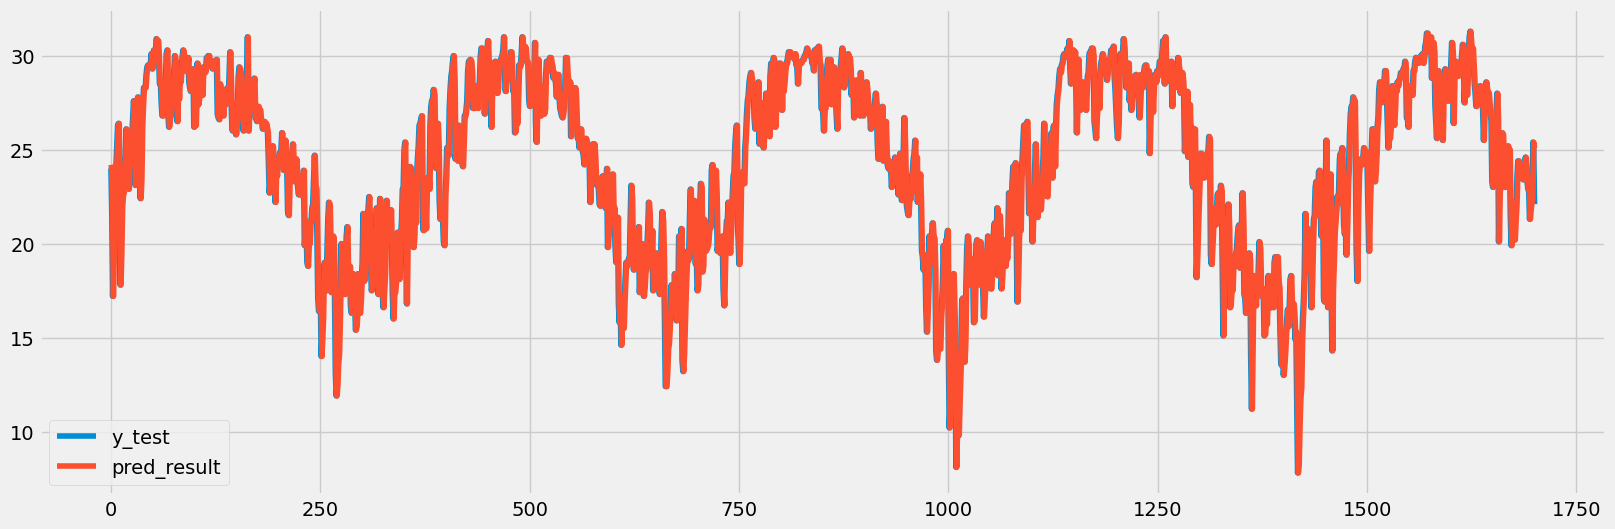

In [14]:
# plot data.y_test

import matplotlib.pyplot as plt
pred_result_np = np.array([item[0][0] for item in pred_result])

# large plot
plt.figure(figsize=(18, 6))

plt.plot(data.y_test, label='y_test')
plt.plot(pred_result_np, label="pred_result")

plt.legend()
plt.grid(visible=True)
# plt.show()
# save plot
plt.savefig('result.png')

In [16]:
# cal the r2 score
from sklearn.metrics import r2_score
r2 = r2_score(data.y_test, pred_result_np)
print(f"R2 score: {r2}")

# cal the mse
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(data.y_test, pred_result_np)
print(f"MSE: {mse}")

# cal the rmse
rmse = np.sqrt(mse) 
print(f"RMSE: {rmse}")


R2 score: 0.9107402905328088
MSE: 1.9681581258773804
RMSE: 1.402910590171814


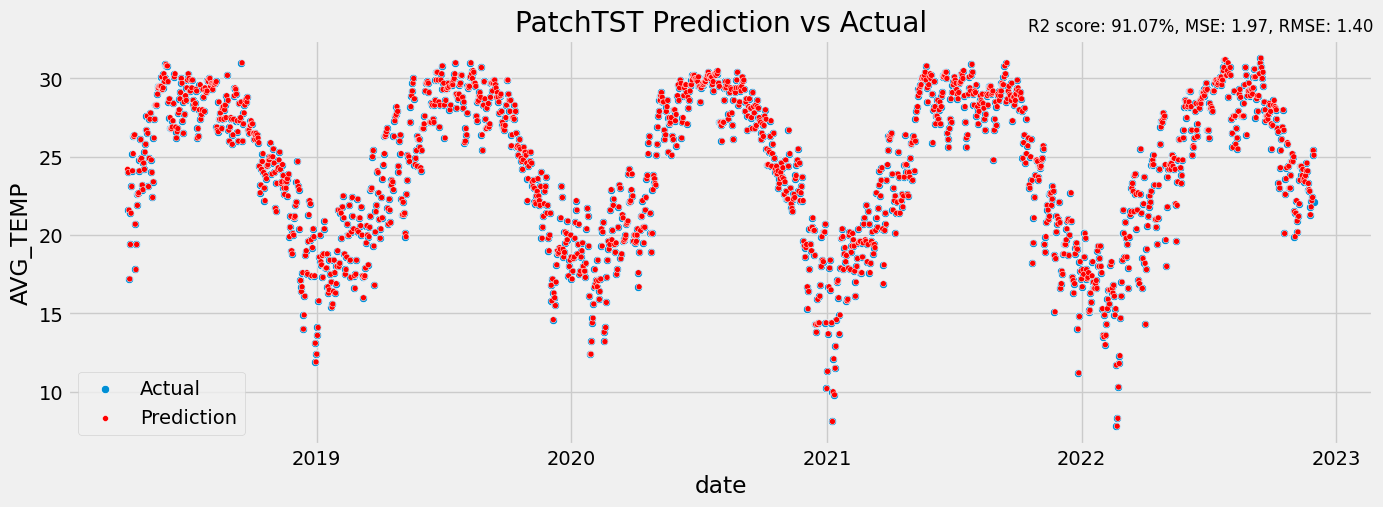

In [32]:
import seaborn as sns

x_values = np.arange(len(pred_result_np))
fig, ax = plt.subplots(figsize=(15, 5),)

plt.title("PatchTST Prediction vs Actual")

# subtitle
plt.title(f"R2 score: {r2*100:.2f}%, MSE: {mse:.2f}, RMSE: {rmse:.2f}", 
             fontsize=12, loc='right')

sns.scatterplot(x=data.date_test, y=data.y_test, )
sns.scatterplot(x=data.date_test, y=pred_result_np, size=0.1, color='red')
plt.legend(["Actual", "Prediction"])

# plt.show()
plt.savefig("result.png")

In [17]:
print(data.y_test)

shape: (1_701,)
Series: 'AVG_TEMP' [f32]
[
	24.0
	21.6
	17.200001
	19.4
	21.4
	…
	22.200001
	22.4
	25.4
	25.1
	22.1
]


In [33]:
print(pred_result_np)

[24.193373 23.993372 21.593372 ... 22.393372 25.393372 25.093372]
